In [237]:
import pyvista as pv
import numpy as np
import pickle 
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from blochK.plotting.utils import extent


with open('spectral_densitys_DLKK_MF_n=0.51_U=6_L=50.pkl', 'rb') as f:
    data = pickle.load(f)    
f.close()

with open('spectral_densitys_Weyl_SOC.pkl', 'rb') as f:
    data = pickle.load(f)    
f.close()

with open('spectral_densitys_Weyl.pkl', 'rb') as f:
    data = pickle.load(f)    
f.close()

spectral_density = data['spectral_density'] 
spin_spectral_density = data['spin_spectral_density']
ks = data['k_mesh']
layers = data['layers']


#create a custom colormap bkr
# grab the endpoints from bwr
cmap_bwr = matplotlib.colormaps["bwr"]
# define your own colormap: blue → black → red
colors = [cmap_bwr(0.0), (0, 0, 0, 1),cmap_bwr(1.0)]
cmap_bkr = LinearSegmentedColormap.from_list("bkr", colors, N=256)


/var/folders/xb/6hhfs1vn32s_g5b9xk9fx8yh0000gn/T/ipykernel_74529/554394838.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap= cm.get_cmap('bwr')  # Blue-White-Red colormap
/Users/valentin/opt/anaconda3/envs/blochk-env/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


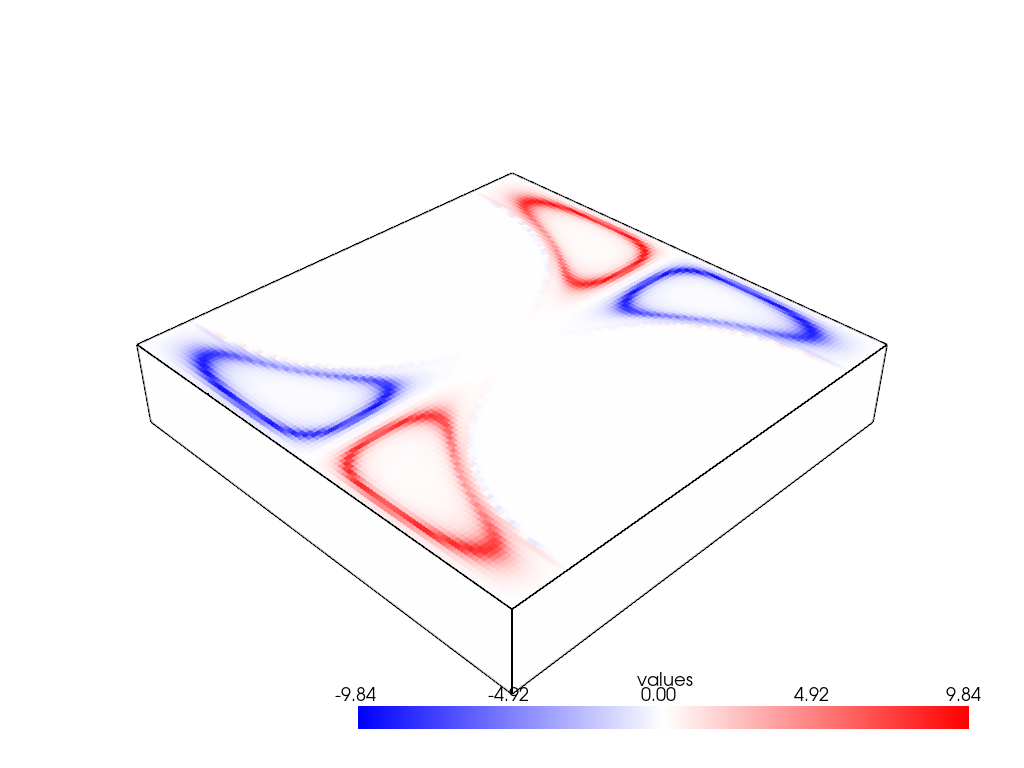

In [223]:


# Create synthetic data
nx, ny, nz = 60, 60, 60
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
z = np.linspace(-1, 1, nz)
xx, yy, zz = np.meshgrid(x, y, z, indexing="ij")

field = np.moveaxis(spin_spectral_density, 0, -1) #.shape = (kx,ky,layers)
alphas = np.moveaxis(spectral_density, 0, -1)/spectral_density.max()

# Create the data grid
grid = pv.ImageData()
grid.dimensions = np.array(field.shape)
grid.origin = (-1, -1, -1)
grid.spacing = (2/nx, 2/ny, 2/nz)
grid["values"] = field.ravel(order="F")

# Create a diverging colormap from matplotlib
cmap = cmap_bkr
cmap= cm.get_cmap('bwr')  # Blue-White-Red colormap

# Determine symmetric bounds around zero
abs_max = np.max(np.abs(field))
clim = [-abs_max, abs_max]
opacity = np.linspace(-abs_max, abs_max, 256)


# Plotting
plotter = pv.Plotter()
plotter.add_volume(
    grid,
    cmap=cmap,
    opacity=1,
    #shade=False,
    clim=clim  # this ensures zero maps to white
)

plotter.add_mesh(grid.outline(), color="black", line_width=2)
plotter.show()

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


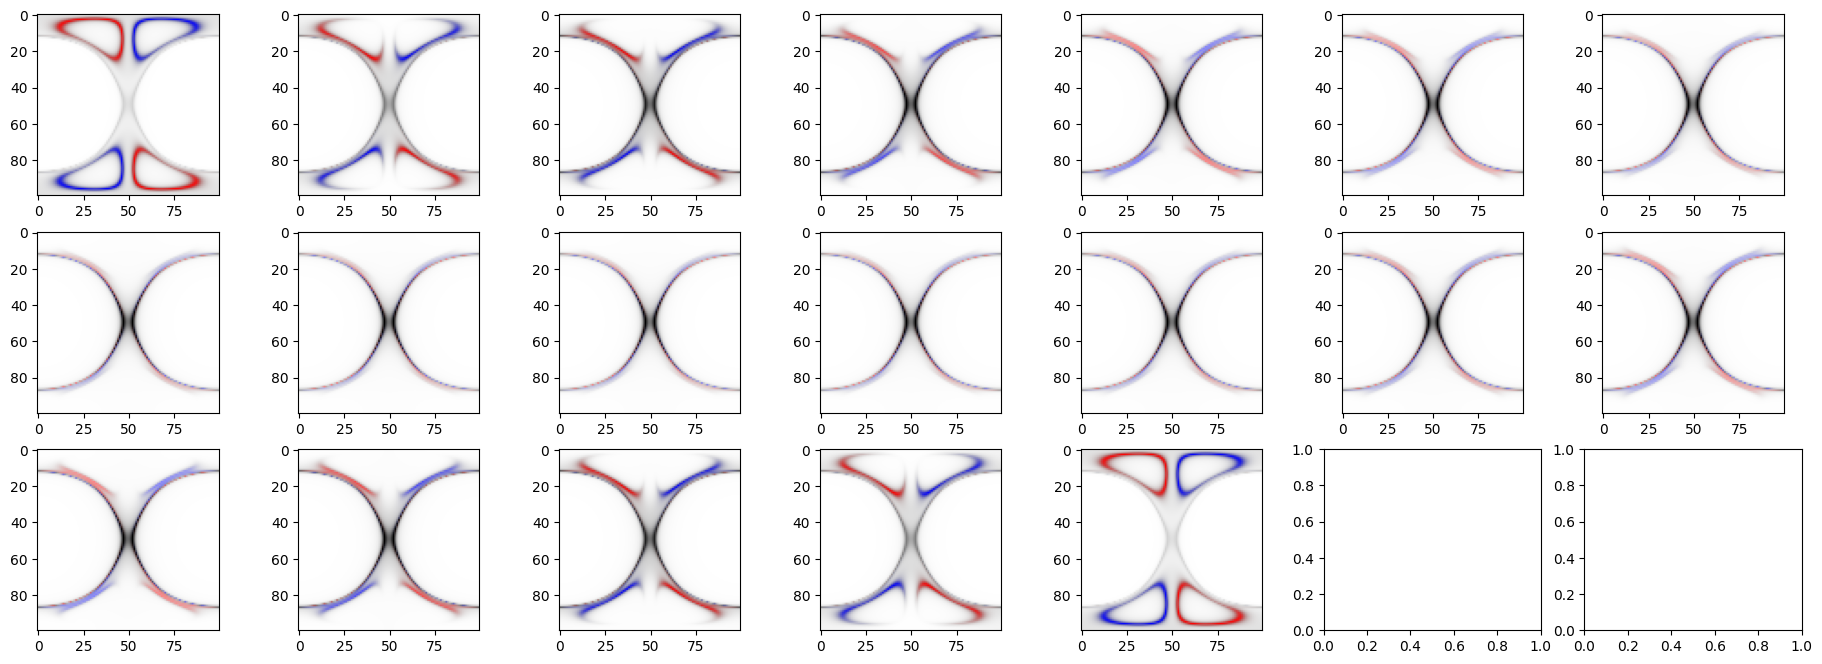

In [225]:
print(layers)
fig,axs = plt.subplots(3,7,figsize=(23,8))

for i,ax in enumerate(axs.flatten()):
    if i>=spectral_density.shape[0]:
        break
    alphas = spectral_density[i]/np.max(np.abs(spectral_density[i]))

    #ax.imshow(spectral_density[i],cmap='gray_r')
    ax.imshow(spin_spectral_density[i],cmap=cmap_bkr,alpha=alphas)

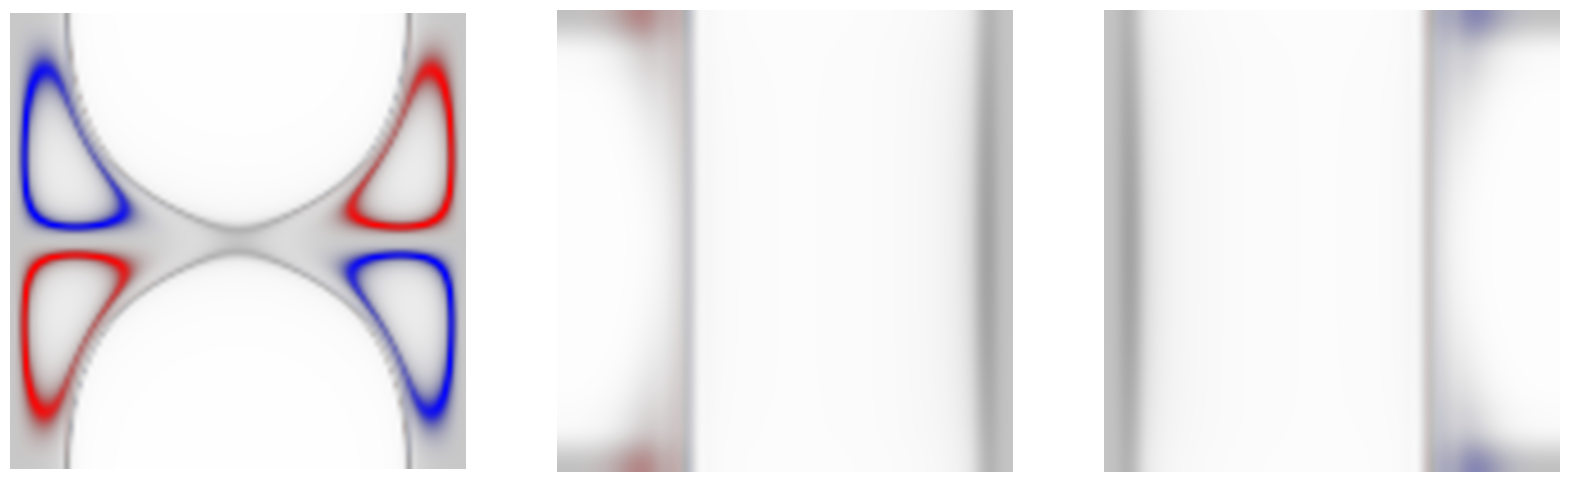

In [239]:
colors = spin_spectral_density.copy()
alphas = spectral_density.copy()
export = True

#nomalize for plotting
colors = spin_spectral_density/np.max(np.abs(spin_spectral_density))
alphas = spectral_density/np.max(np.abs(spectral_density))

#power law for better visibility
colors = np.sign(colors)*np.abs(colors)**0.85
alphas = alphas**0.7

imshow_kwargs = dict(origin='lower',vmax=1, vmin=-1,interpolation='spline36')

fig,axs = plt.subplots(1,3,figsize=(20,6))
numb_ks = ks.shape[1]




#########################################
#surface
#########################################
axs[0].set_title('Specral Density layer 0')
axs[0].set_xlabel('$k_x$')
axs[0].set_ylabel('$k_y$')
i=0
colors0 = colors[i].T
alphas0 = alphas[i].T
axs[0].imshow(colors0,cmap=cmap_bkr,alpha=alphas0,**imshow_kwargs,extent=extent(numb_ks))
#the lines where we cut


#########################################
#cut along ky
#########################################
axs[1].set_xlabel('$k_x, k_y$')
axs[1].set_ylabel('Layer index')
idx_ky = spectral_density.shape[1]//2-1
axs[1].set_title('Spectral Density at k_x=k_y')
#cut
colors0 = colors[:,range(numb_ks),range(numb_ks)]
alphas0 = alphas[:,range(numb_ks),range(numb_ks)]
axs[1].imshow(colors0,cmap=cmap_bkr,alpha=alphas0,extent=[-np.pi,np.pi,layers[0],layers[-1]],aspect='auto',**imshow_kwargs)
axs[1].set_xlim(-np.pi,0)

#########################################
#cut along ky
#########################################
axs[2].set_xlabel('$k_x,-k_y$')
axs[2].set_ylabel('Layer index')
idx_ky = spectral_density.shape[1]//2-1
axs[2].set_title('Spectral Density at k_x=-k_y')
#cut
colors0 = colors[:,range(numb_ks),range(-1,-numb_ks-1,-1)]
alphas0 = alphas[:,range(numb_ks),range(-1,-numb_ks-1,-1)]
axs[2].imshow(colors0,cmap=cmap_bkr,alpha=alphas0,extent=[-np.pi,np.pi,layers[0],layers[-1]],aspect='auto',**imshow_kwargs)
axs[2].set_xlim(0,np.pi)


if export:
    for ax in axs:
        ax.set_title('')
        ax.set_axis_off()

    fig.savefig('spectral_density_cut.pdf',bbox_inches='tight')
else:
    axs[0].plot([-np.pi,0,np.pi], [-np.pi, 0, -np.pi], color='k', linestyle='--')



(100, 100, 10)
(100, 100, 10, 4)


/Users/valentin/opt/anaconda3/envs/blochk-env/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


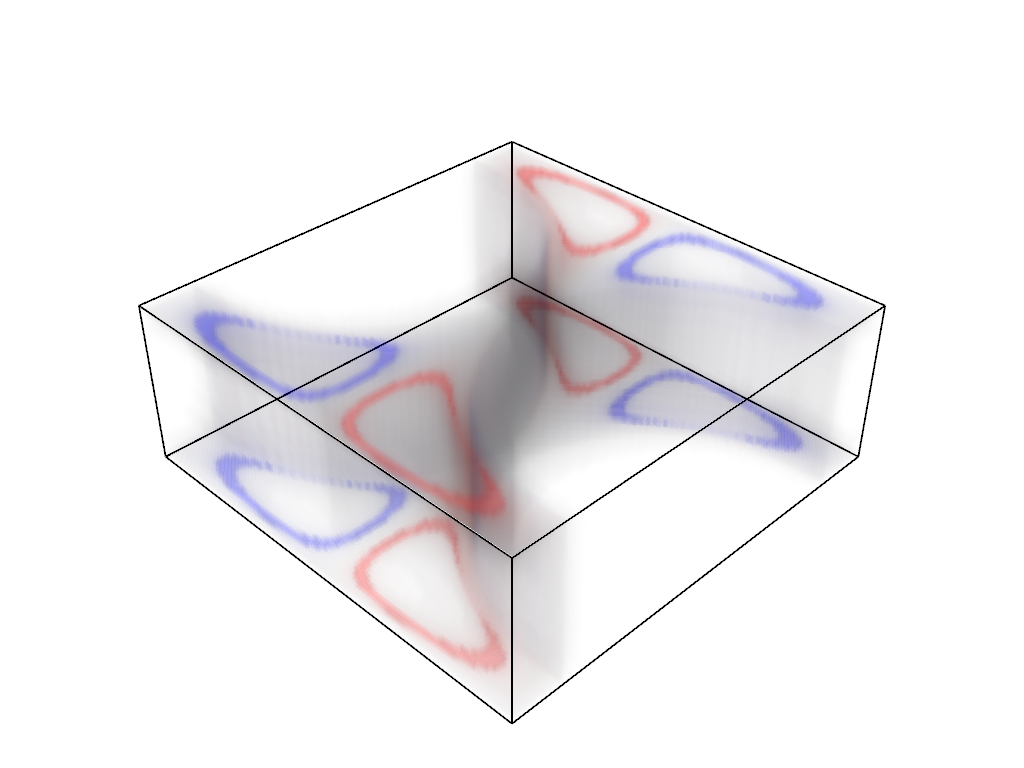

In [220]:
import numpy as np
import pyvista as pv
from matplotlib import cm

# ----------------------------
# Replace these with your arrays
# ----------------------------
# Example shapes (nx,ny,nz)


# spin_spectral_density: the scalar field you want to color by (float)
# spectral_density: the second array that controls per-voxel opacity (float, >=0)
# Here I create example arrays. Replace with your real arrays.
field_color = np.moveaxis(spin_spectral_density[::2], 0, -1)  # example in [-0.2,0.2]
weights = np.moveaxis(spectral_density[::2], 0, -1) 


#blur the data a bit
from scipy.ndimage import gaussian_filter
#field_color = gaussian_filter(field_color, sigma=0.5)
# alpha_src = gaussian_filter(alpha_src, sigma=0.5)

weights /= weights.max()  # normalize to [0,1]
weights = weights**0.3 *1.2 #scale to enhance contrast

(nx, ny, nz) = field_color.shape
print((nx, ny, nz))
# ----------------------------
# Build the RGBA volume
# ----------------------------

# 2) normalize spin into [0,1] for colormap lookup
field_color = np.abs(field_color)**0.5 * np.sign(field_color)  # optional: enhance contrast at the edge
field_color_min, field_color_max = float(field_color.min()), float(field_color.max())
field_color_norm = (field_color - field_color_min) / (field_color_max - field_color_min)


# 3) map normalized spin to RGB (returns NxMx3 or NxMx4; take first 3 channels)
rgb = cmap_bkr(field_color_norm)[..., :3]  # floats in [0,1]

# 4) use weights (or a derived version) as per-voxel opacity (0..1)
weights = np.clip(weights, 0., 1) 
weights = (weights>0.2) * weights  # threshold small opacities to zero

# 5) compose RGBA float array (shape: nx,ny,nz,4)
rgba = np.empty(field_color.shape + (4,))
rgba[..., :3] = rgb
rgba[..., 3] = weights
rgba_uint8 = (np.clip(rgba, 0.0, 1.0) * 255).astype(np.uint8) #convert to uint8 0..255 as VTK expects unsigned char RGBA

#tune to white background
# rgba = np.empty(field_color.shape + (4,))
# rgba[..., :3] = rgb * weights[..., None] + (1 - weights[..., None]) * 1.

# rgba[..., 3] = 1
# rgba_uint8 = (np.clip(rgba, 0.0, 1.0) * 255).astype(np.uint8) #convert to uint8 0..255 as VTK expects unsigned char RGBA

# ----------------------------
# Create PyVista ImageData and assign RGBA scalars
# ----------------------------
grid = pv.ImageData()
grid.dimensions = np.array(field_color.shape)  # (nx, ny, nz)
grid.origin = (-1, -1, -1)
grid.spacing = (2.0 / nx, 2.0 / ny, 2.0 / nx*4) #use nx instead of nz

# Flatten to (n_points, 4) and assign
print(rgba_uint8.shape)
grid.point_data["RGB"] = rgba_uint8[..., :3].reshape((-1, 3), order="F") # Assign as point data (unsigned byte RGBA)
grid.point_data["RGBA"] = rgba_uint8.reshape((-1, 4), order="F") # Assign as point data (unsigned byte RGBA)
grid.set_active_scalars("RGBA")  # mark as active scalars



#RGBA version using alpha



# ----------------------------
# Render: use add_volume with rgb=True (preferred) or fallback
# ----------------------------
p = pv.Plotter()
p.add_volume(grid, scalars="RGBA", shade=False)


p.add_mesh(grid.outline(), color="black", line_width=2)
p.show()  # or p.show(screenshot="out.png") to save an image

In [166]:
iso = grid.contour(isosurfaces=[0.0])   # or any value(s)
p = pv.Plotter()
p.add_mesh(iso, rgb=True)
p.show()

ValueError: RGB array must be n_points/n_cells by 3/4 in shape.